# Análise de Clustering

## Tech Challenge Fase 3 - Machine Learning Engineering

**Objetivo:** Aplicar técnicas de aprendizado não supervisionado (clustering) para identificar padrões e segmentos nos dados de voos.

### Estrutura da Análise:
1. Preparação dos Dados para Clustering
2. K-Means Clustering
3. DBSCAN Clustering
4. Clustering Hierárquico
5. Comparação e Avaliação dos Modelos
6. Interpretação dos Clusters

In [1]:
# Imports e Configurações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys

# Adiciona o diretório raiz ao path para importar módulos locais
sys.path.append('..')

# Imports dos módulos locais
from src.unsupervised.clustering import (
    prepare_data_for_clustering,
    apply_kmeans,
    find_optimal_k,
    apply_dbscan,
    find_dbscan_params,
    apply_hierarchical,
    evaluate_clustering,
    plot_clusters_2d,
    plot_cluster_distribution,
    plot_cluster_profiles
)

from src.unsupervised.evaluate import (
    evaluate_clustering_internal,
    evaluate_clustering_external,
    analyze_cluster_composition,
    get_cluster_centroids,
    get_cluster_sizes,
    plot_silhouette_analysis,
    plot_cluster_comparison,
    generate_clustering_report,
    create_evaluation_dataframe
)

from src.unsupervised.dimensionality import apply_pca

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Seed para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Cores para gráficos
COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


---
## 1. Preparação dos Dados para Clustering

In [2]:
# Carrega os dados processados da EDA
df = pd.read_parquet('../data/processed/flights_processed.parquet')
print(f'Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
df.head()

Dataset carregado: 5,729,195 linhas × 50 colunas


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IS_DELAYED,DELAY_CATEGORY,PERIOD,HOUR,DATE,MONTH_NAME,DAY_NAME,ROUTE,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_LAT,ORIGIN_LON,DEST_AIRPORT_NAME,DEST_CITY,DEST_STATE,DEST_LAT,DEST_LON
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.00,-11.00,21.00,15.00,205.00,194.00,169.00,1448,404.00,4.00,430,408.00,-22.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Adiantado,Madrugada (21h-5h),0,2015-01-01,Janeiro,Quinta,ANC → SEA,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,61.17,-150.00,Seattle-Tacoma International Airport,Seattle,WA,47.45,-122.31
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.00,-8.00,12.00,14.00,280.00,279.00,263.00,2330,737.00,4.00,750,741.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Adiantado,Madrugada (21h-5h),0,2015-01-01,Janeiro,Quinta,LAX → PBI,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,33.94,-118.41,Palm Beach International Airport,West Palm Beach,FL,26.68,-80.10
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.00,-2.00,16.00,34.00,286.00,293.00,266.00,2296,800.00,11.00,806,811.00,5.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Atraso Leve (<15min),Madrugada (21h-5h),0,2015-01-01,Janeiro,Quinta,SFO → CLT,US Airways Inc.,San Francisco International Airport,San Francisco,CA,37.62,-122.37,Charlotte Douglas International Airport,Charlotte,NC,35.21,-80.94
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.00,-5.00,15.00,30.00,285.00,281.00,258.00,2342,748.00,8.00,805,756.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Adiantado,Madrugada (21h-5h),0,2015-01-01,Janeiro,Quinta,LAX → MIA,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,33.94,-118.41,Miami International Airport,Miami,FL,25.79,-80.29
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.00,-1.00,11.00,35.00,235.00,215.00,199.00,1448,254.00,5.00,320,259.00,-21.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Adiantado,Madrugada (21h-5h),0,2015-01-01,Janeiro,Quinta,SEA → ANC,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,47.45,-122.31,Ted Stevens Anchorage International Airport,Anchorage,AK,61.17,-150.00


In [3]:
# Verifica as colunas disponíveis
print('Colunas disponíveis:')
print(df.columns.tolist())

Colunas disponíveis:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'IS_DELAYED', 'DELAY_CATEGORY', 'PERIOD', 'HOUR', 'DATE', 'MONTH_NAME', 'DAY_NAME', 'ROUTE', 'AIRLINE_NAME', 'ORIGIN_AIRPORT_NAME', 'ORIGIN_CITY', 'ORIGIN_STATE', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_AIRPORT_NAME', 'DEST_CITY', 'DEST_STATE', 'DEST_LAT', 'DEST_LON']


In [4]:
# =============================================================================
# PREPARAÇÃO DOS DADOS COM CONTEXTO OPERACIONAL COMPLETO
# =============================================================================

SAMPLE_SIZE = 100000

# Filtra apenas voos não cancelados
df_valid = df[df['CANCELLED'] == 0].copy()
print(f'Voos não cancelados: {len(df_valid):,}')

# =============================================================================
# FEATURE ENGINEERING PARA CLUSTERING
# =============================================================================

# 1. Cria HOUR se não existir
if 'HOUR' not in df_valid.columns:
    df_valid['HOUR'] = (df_valid['SCHEDULED_DEPARTURE'] // 100).astype(int)
    df_valid['HOUR'] = df_valid['HOUR'].clip(0, 23)  # Garante valores válidos
    print('✅ HOUR criada')

# 2. Cria PERIOD_ENCODED (encoding numérico do período do dia)
# A coluna PERIOD já existe no dataset com valores texto, precisamos encodar
if 'PERIOD' in df_valid.columns and df_valid['PERIOD'].dtype == 'object':
    # Encoding da coluna PERIOD existente (texto -> numérico)
    le_period = LabelEncoder()
    df_valid['PERIOD_ENCODED'] = le_period.fit_transform(df_valid['PERIOD'].astype(str))
    print(f'✅ PERIOD_ENCODED criada a partir da coluna existente')
    print(f'   Classes: {dict(zip(le_period.classes_, range(len(le_period.classes_))))}')
else:
    # Se não existe, cria a partir da hora
    def get_period(hour):
        if 5 <= hour < 12:
            return 0  # Manhã
        elif 12 <= hour < 18:
            return 1  # Tarde
        elif 18 <= hour < 22:
            return 2  # Noite
        else:
            return 3  # Madrugada
    
    df_valid['PERIOD_ENCODED'] = df_valid['HOUR'].apply(get_period)
    print('✅ PERIOD_ENCODED criada (0=Manhã, 1=Tarde, 2=Noite, 3=Madrugada)')

# 3. Encoding da companhia aérea (Label Encoding)
from sklearn.preprocessing import LabelEncoder
le_airline = LabelEncoder()
df_valid['AIRLINE_ENCODED'] = le_airline.fit_transform(df_valid['AIRLINE'].astype(str))
print(f'✅ AIRLINE_ENCODED criada ({len(le_airline.classes_)} companhias)')

# 4. Encoding do aeroporto de origem (Top N + Outros)
# Agrupa aeroportos menos frequentes como "OUTROS" para evitar alta cardinalidade
TOP_N_AIRPORTS = 50
top_origin_airports = df_valid['ORIGIN_AIRPORT'].value_counts().head(TOP_N_AIRPORTS).index.tolist()
df_valid['ORIGIN_AIRPORT_GROUPED'] = df_valid['ORIGIN_AIRPORT'].apply(
    lambda x: x if x in top_origin_airports else 'OTHER'
)
le_origin_airport = LabelEncoder()
df_valid['ORIGIN_AIRPORT_ENCODED'] = le_origin_airport.fit_transform(df_valid['ORIGIN_AIRPORT_GROUPED'])
print(f'✅ ORIGIN_AIRPORT_ENCODED criada (Top {TOP_N_AIRPORTS} + OTHER)')

# 5. Encoding do aeroporto de destino (Top N + Outros)
top_dest_airports = df_valid['DESTINATION_AIRPORT'].value_counts().head(TOP_N_AIRPORTS).index.tolist()
df_valid['DEST_AIRPORT_GROUPED'] = df_valid['DESTINATION_AIRPORT'].apply(
    lambda x: x if x in top_dest_airports else 'OTHER'
)
le_dest_airport = LabelEncoder()
df_valid['DEST_AIRPORT_ENCODED'] = le_dest_airport.fit_transform(df_valid['DEST_AIRPORT_GROUPED'])
print(f'✅ DEST_AIRPORT_ENCODED criada (Top {TOP_N_AIRPORTS} + OTHER)')

# =============================================================================
# DEFINIÇÃO DAS FEATURES PARA CLUSTERING (OTIMIZADAS)
# =============================================================================
# Removido: DEPARTURE_DELAY (correlação 0.97 com ARRIVAL_DELAY)
# Removido: PERIOD_ENCODED (correlação 0.88 com HOUR)
# Adicionado: DEST_AIRPORT_ENCODED (contexto do destino)

features_clustering = [
    # Métrica de atraso (apenas ARRIVAL - principal métrica para passageiros)
    'ARRIVAL_DELAY',
    
    # Características operacionais do voo
    'DISTANCE',
    'TAXI_OUT',
    'TAXI_IN',
    
    # Contexto temporal (HOUR é mais granular que PERIOD)
    'HOUR',
    'DAY_OF_WEEK',
    'MONTH',
    
    # Contexto operacional (origem E destino)
    'AIRLINE_ENCODED',
    'ORIGIN_AIRPORT_ENCODED',
    'DEST_AIRPORT_ENCODED'
]

print(f'\n📊 Features selecionadas para clustering ({len(features_clustering)}):')
for i, feat in enumerate(features_clustering, 1):
    print(f'   {i:2d}. {feat}')

# Remove registros com valores faltantes nas features selecionadas
df_valid = df_valid.dropna(subset=features_clustering)
print(f'\nRegistros válidos para clustering: {len(df_valid):,}')

# =============================================================================
# AMOSTRAGEM ESTRATIFICADA
# =============================================================================

# Amostra estratificada por DELAY_CATEGORY para manter proporções
if 'DELAY_CATEGORY' in df_valid.columns:
    n_categories = df_valid['DELAY_CATEGORY'].nunique()
    samples_per_category = SAMPLE_SIZE // n_categories
    
    df_sample = df_valid.groupby('DELAY_CATEGORY', group_keys=False).apply(
        lambda x: x.sample(min(len(x), samples_per_category), random_state=RANDOM_STATE)
    )
else:
    df_sample = df_valid.sample(n=min(SAMPLE_SIZE, len(df_valid)), random_state=RANDOM_STATE)

# Reset index para evitar problemas
df_sample = df_sample.reset_index(drop=True)

print(f'\n🎯 Amostra para clustering: {len(df_sample):,} registros')

if 'DELAY_CATEGORY' in df_sample.columns:
    print(f'\nDistribuição por categoria de atraso:')
    print(df_sample['DELAY_CATEGORY'].value_counts())

Voos não cancelados: 5,729,195
✅ PERIOD_ENCODED criada (0=Manhã, 1=Tarde, 2=Noite, 3=Madrugada)
✅ AIRLINE_ENCODED criada (14 companhias)
✅ ORIGIN_AIRPORT_ENCODED criada (Top 50 + OTHER)
✅ DEST_AIRPORT_ENCODED criada (Top 50 + OTHER)

📊 Features selecionadas para clustering (10):
    1. ARRIVAL_DELAY
    2. DISTANCE
    3. TAXI_OUT
    4. TAXI_IN
    5. HOUR
    6. DAY_OF_WEEK
    7. MONTH
    8. AIRLINE_ENCODED
    9. ORIGIN_AIRPORT_ENCODED
   10. DEST_AIRPORT_ENCODED

Registros válidos para clustering: 5,714,008

🎯 Amostra para clustering: 99,996 registros


In [5]:
df_sample.info()
display(df_sample)

<class 'pandas.DataFrame'>
RangeIndex: 99996 entries, 0 to 99995
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   YEAR                    99996 non-null  int64         
 1   MONTH                   99996 non-null  int64         
 2   DAY                     99996 non-null  int64         
 3   DAY_OF_WEEK             99996 non-null  int64         
 4   AIRLINE                 99996 non-null  str           
 5   FLIGHT_NUMBER           99996 non-null  int64         
 6   TAIL_NUMBER             99996 non-null  str           
 7   ORIGIN_AIRPORT          99996 non-null  str           
 8   DESTINATION_AIRPORT     99996 non-null  str           
 9   SCHEDULED_DEPARTURE     99996 non-null  int64         
 10  DEPARTURE_TIME          99996 non-null  float64       
 11  DEPARTURE_DELAY         99996 non-null  float64       
 12  TAXI_OUT                99996 non-null  float64       
 1

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IS_DELAYED,PERIOD,HOUR,DATE,MONTH_NAME,DAY_NAME,ROUTE,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_LAT,ORIGIN_LON,DEST_AIRPORT_NAME,DEST_CITY,DEST_STATE,DEST_LAT,DEST_LON,PERIOD_ENCODED,AIRLINE_ENCODED,ORIGIN_AIRPORT_GROUPED,ORIGIN_AIRPORT_ENCODED,DEST_AIRPORT_GROUPED,DEST_AIRPORT_ENCODED
0,2015,2,3,2,AA,1424,N4WLAA,ABQ,DFW,1535,1530.00,-5.00,8.00,1538.00,103.00,97.00,78.00,569,1756.00,11.00,1818,1807.00,-11.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Tarde (12h-17h),15,2015-02-03,Fevereiro,Terça,ABQ → DFW,American Airlines Inc.,Albuquerque International Sunport,Albuquerque,NM,35.04,-106.61,Dallas/Fort Worth International Airport,Dallas-Fort Worth,TX,32.90,-97.04,1,0,OTHER,34,DFW,12
1,2015,3,20,5,EV,6126,N14950,ELM,ORD,1700,1700.00,0.00,10.00,1710.00,130.00,122.00,101.00,566,1751.00,11.00,1810,1802.00,-8.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Noite (17h-21h),17,2015-03-20,Março,Sexta,ELM → ORD,Atlantic Southeast Airlines,Elmira/Corning Regional Airport,Elmira,NY,42.16,-76.89,Chicago O'Hare International Airport,Chicago,IL,41.98,-87.90,1,4,OTHER,34,ORD,33
2,2015,4,28,2,VX,879,N524VA,LGA,DAL,700,648.00,-12.00,10.00,658.00,240.00,210.00,196.00,1381,914.00,4.00,1000,918.00,-42.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Manhã (5h-12h),7,2015-04-28,Abril,Terça,LGA → DAL,Virgin America,LaGuardia Airport (Marine Air Terminal),New York,NY,40.78,-73.87,Dallas Love Field,Dallas,TX,32.85,-96.85,0,12,LGA,24,DAL,9
3,2015,8,25,2,AA,2120,N820AW,DCA,BOS,1630,1625.00,-5.00,17.00,1642.00,91.00,79.00,53.00,399,1735.00,9.00,1801,1744.00,-17.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Tarde (12h-17h),16,2015-08-25,Agosto,Terça,DCA → BOS,American Airlines Inc.,Ronald Reagan Washington National Airport,Arlington,VA,38.85,-77.04,Gen. Edward Lawrence Logan International Airport,Boston,MA,42.36,-71.01,1,0,DCA,10,BOS,5
4,2015,8,22,6,WN,4189,N7708E,LAS,BNA,1550,1608.00,18.00,8.00,1616.00,215.00,195.00,182.00,1587,2118.00,5.00,2125,2123.00,-2.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Tarde (12h-17h),15,2015-08-22,Agosto,Sábado,LAS → BNA,Southwest Airlines Co.,McCarran International Airport,Las Vegas,NV,36.08,-115.15,Nashville International Airport,Nashville,TN,36.12,-86.68,1,13,LAS,22,BNA,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99991,2015,7,10,5,WN,1393,N8325D,MDW,BWI,1325,1329.00,4.00,15.00,1344.00,110.00,106.00,87.00,611,1611.00,4.00,1615,1615.00,0.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Tarde (12h-17h),13,2015-07-10,Julho,Sexta,MDW → BWI,Southwest Airlines Co.,Chicago Midway International Airport,Chicago,IL,41.79,-87.75,Baltimore-Washington International Airport,Baltimore,MD,39.18,-76.67,1,13,MDW,27,BWI,6
99992,2015,7,4,6,DL,2528,N920AT,CLE,ATL,1500,1517.00,17.00,10.00,1527.00,109.00,92.00,78.00,554,1645.00,4.00,1649,1649.00,0.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Tarde (12h-17h),15,2015-07-04,Julho,Sábado,CLE → ATL,Delta Air Lines Inc.,Cleveland Hopkins International Airport,Cleveland,OH,41.41,-81.85,Hartsfield-Jackson Atlanta International Airport,Atlanta,GA,33.64,-84.43,1,3,CLE,7,ATL,2
99993,2015,9,23,3,WN,1813,N946WN,MDW,ROC,1330,1331.00,1.00,14.00,1345.00,90.00,89.00,71.00,523,1556.00,4.00,1600,1600.00,0.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,Tarde (12h-17h),13,2015-09-23,Setembro,Quarta,MDW → ROC,Southwest Airlines Co.,Chicago Midway International Airport,Chicago,IL,41.79,-87.75,Greater Rochester International Airport,Rochester,NY,43.12,-77.67,1,13,MDW,27,OTHER,34
99994,2015,4,1,3,WN,555,N795SW,SAN,AUS,1435,1452.00,17.00

In [6]:
# Prepara os dados para clustering (normalização)
X_scaled, scaler, feature_names = prepare_data_for_clustering(
    df_sample,
    features=features_clustering,
    method='standard'
)

print(f'Shape dos dados normalizados: {X_scaled.shape}')
print(f'Features utilizadas: {feature_names}')

Shape dos dados normalizados: (99996, 10)
Features utilizadas: ['ARRIVAL_DELAY', 'DISTANCE', 'TAXI_OUT', 'TAXI_IN', 'HOUR', 'DAY_OF_WEEK', 'MONTH', 'AIRLINE_ENCODED', 'ORIGIN_AIRPORT_ENCODED', 'DEST_AIRPORT_ENCODED']


Estatísticas dos dados normalizados:


,ARRIVAL_DELAY,DISTANCE,TAXI_OUT,TAXI_IN,HOUR,DAY_OF_WEEK,MONTH,AIRLINE_ENCODED,ORIGIN_AIRPORT_ENCODED,DEST_AIRPORT_ENCODED
count,99996.00,99996.00,99996.00,99996.00,99996.00,99996.00,99996.00,99996.00,99996.00,99996.00
mean,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.36,-1.31,-1.34,-0.89,-2.90,-1.45,-1.58,-1.50,-1.95,-1.97
25%,-0.60,-0.74,-0.58,-0.52,-0.78,-0.95,-0.99,-0.85,-0.95,-0.89
50%,-0.43,-0.28,-0.28,-0.28,0.07,0.06,-0.11,0.03,0.36,0.34
75%,0.36,0.40,0.17,0.08,0.92,1.06,0.78,0.90,0.66,0.65
max,16.68,6.95,15.54,20.30,1.99,1.56,1.66,1.34,1.89,1.88



📊 Matriz de Correlação das Features:


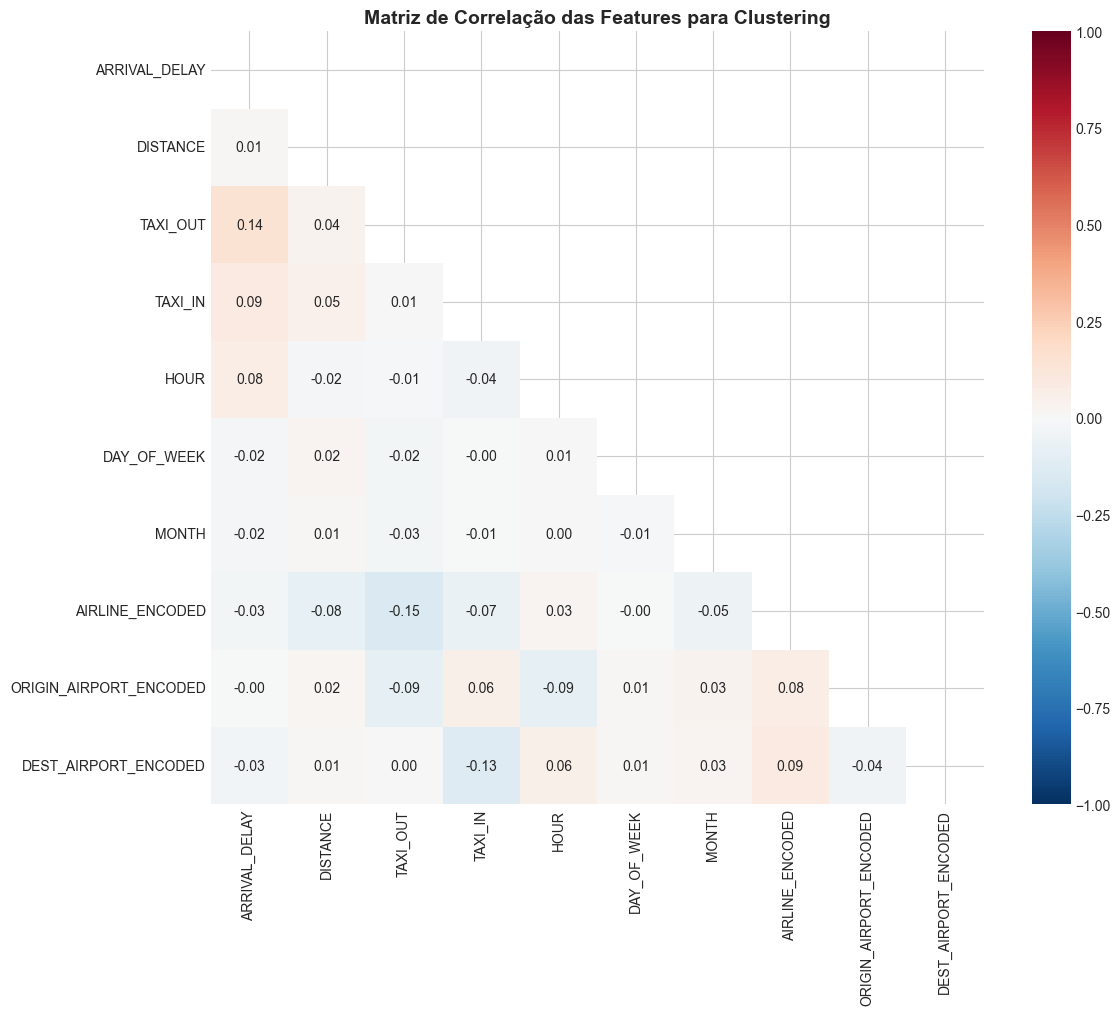


⚠️ Correlações altas (|r| > 0.7):
   Nenhuma correlação alta encontrada. Features bem selecionadas!


In [7]:
# Estatísticas descritivas dos dados normalizados
df_scaled = pd.DataFrame(X_scaled, columns=feature_names)
print('Estatísticas dos dados normalizados:')
display(df_scaled.describe())

# Matriz de correlação para verificar redundância
print('\n📊 Matriz de Correlação das Features:')
fig, ax = plt.subplots(figsize=(12, 10))
correlation_matrix = df_scaled.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    square=True
)
ax.set_title('Matriz de Correlação das Features para Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/unsupervised/clustering_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Identifica correlações altas
print('\n⚠️ Correlações altas (|r| > 0.7):')
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlação': correlation_matrix.iloc[i, j]
            })
            
if high_corr:
    display(pd.DataFrame(high_corr).sort_values('Correlação', ascending=False))
else:
    print('   Nenhuma correlação alta encontrada. Features bem selecionadas!')

---
## 2. K-Means Clustering

O K-Means é um dos algoritmos de clustering mais populares. Ele particiona os dados em K clusters, minimizando a variância dentro de cada cluster.

🔍 Buscando K ótimo de 2 a 10...
   K=2: Silhouette=0.0988, Inertia=911730
   K=3: Silhouette=0.0926, Inertia=851357
   K=4: Silhouette=0.0887, Inertia=800786
   K=5: Silhouette=0.1003, Inertia=751219
   K=6: Silhouette=0.1077, Inertia=704655
   K=7: Silhouette=0.1074, Inertia=671734
   K=8: Silhouette=0.1023, Inertia=642337
   K=9: Silhouette=0.1022, Inertia=619463
   K=10: Silhouette=0.0991, Inertia=601157

✅ K ótimo sugerido: 6 (melhor Silhouette Score)


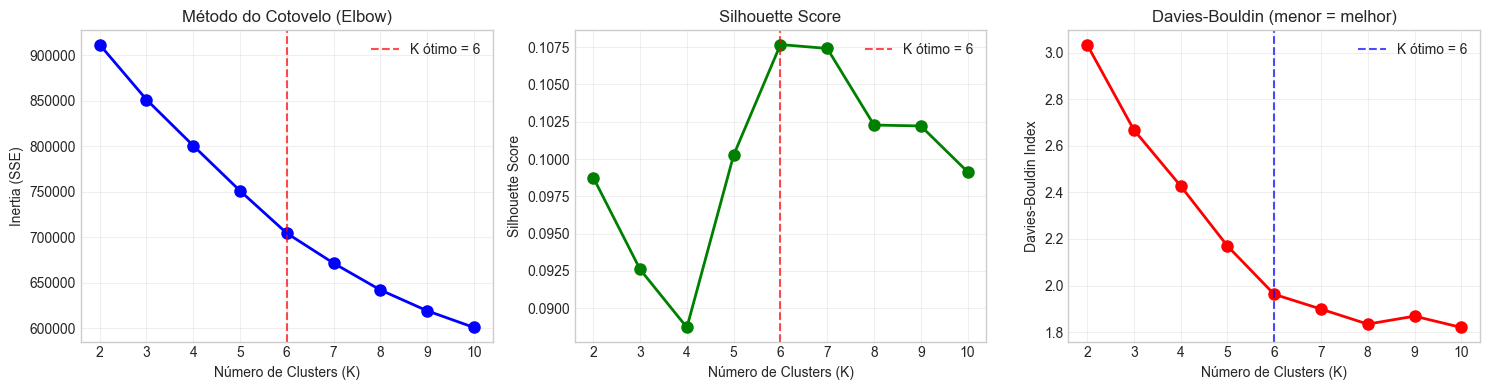

In [8]:
# Encontra o número ótimo de clusters usando método do cotovelo e silhouette
optimal_k_results = find_optimal_k(
    X_scaled,
    k_range=range(2, 11),
    random_state=RANDOM_STATE
)

In [9]:
# Analisa os resultados para diferentes valores de K
# Remove a chave 'optimal_k' para criar o DataFrame (não é uma lista)
df_kmeans_results = pd.DataFrame({k: v for k, v in optimal_k_results.items() if k != 'optimal_k'})
print('Resultados para diferentes valores de K:')
display(df_kmeans_results)

# Destaca o K ótimo
print(f'\n🎯 K ótimo sugerido: {optimal_k_results["optimal_k"]}')

Resultados para diferentes valores de K:


,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,911729.85,0.10,3.03,9676.74
1,3,851356.81,0.09,2.67,8726.84
2,4,800786.47,0.09,2.43,8290.11
3,5,751219.30,0.10,2.17,8277.18
4,6,704655.32,0.11,1.96,8380.70
5,7,671733.54,0.11,1.90,8142.89
6,8,642336.68,0.10,1.83,7952.70
7,9,619462.76,0.10,1.87,7677.00
8,10,601157.22,0.10,1.82,7370.03



🎯 K ótimo sugerido: 6


In [10]:
# Seleciona K baseado no melhor silhouette score
best_k = optimal_k_results['optimal_k']
print(f'K ótimo baseado no Silhouette Score: {best_k}')

# Você pode ajustar manualmente se necessário
K_SELECTED = int(best_k)
print(f'\n📌 K selecionado para clustering: {K_SELECTED}')

K ótimo baseado no Silhouette Score: 6

📌 K selecionado para clustering: 6


In [11]:
# Aplica K-Means com o K selecionado
kmeans_labels, kmeans_model, kmeans_metrics = apply_kmeans(
    X_scaled,
    n_clusters=K_SELECTED,
    random_state=RANDOM_STATE
)

print(f'K-Means com K={K_SELECTED}')
print(f'Inertia: {kmeans_metrics["inertia"]:.2f}')
print(f'Silhouette Score: {kmeans_metrics["silhouette_score"]:.4f}')
print(f'Davies-Bouldin Index: {kmeans_metrics["davies_bouldin_score"]:.4f}')
print(f'Calinski-Harabasz Index: {kmeans_metrics["calinski_harabasz_score"]:.2f}')

K-Means com K=6
Inertia: 704655.32
Silhouette Score: 0.1077
Davies-Bouldin Index: 1.9624
Calinski-Harabasz Index: 8380.70


In [12]:
# Adiciona labels ao DataFrame
df_sample['CLUSTER_KMEANS'] = kmeans_labels

# Distribuição dos clusters
print('Distribuição dos clusters K-Means:')
print(df_sample['CLUSTER_KMEANS'].value_counts().sort_index())

Distribuição dos clusters K-Means:
CLUSTER_KMEANS
0    25250
1    25556
2     4860
3    12948
4     2203
5    29179
Name: count, dtype: int64


✅ Figura salva em: ../reports/figures/unsupervised/kmeans_clusters_2d.png


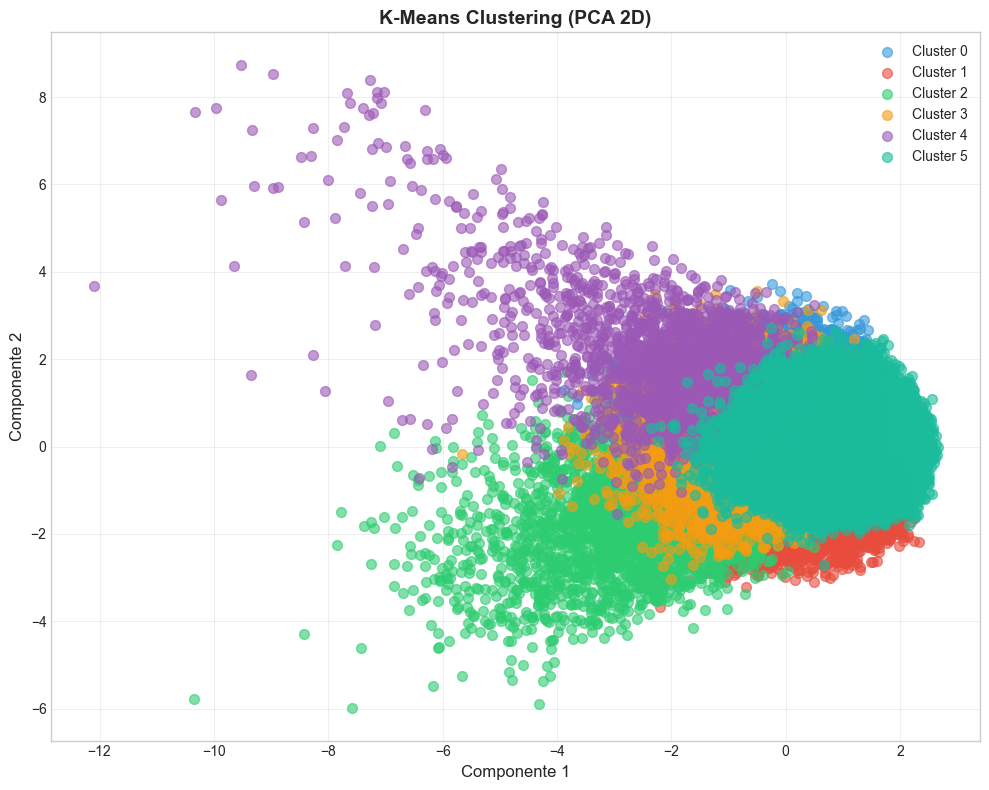

In [13]:
# Visualização dos clusters com PCA para redução a 2D
X_pca, pca_model, _ = apply_pca(X_scaled, n_components=2)

fig = plot_clusters_2d(
    X_pca,
    kmeans_labels,
    title='K-Means Clustering (PCA 2D)',
    save_path='../reports/figures/unsupervised/kmeans_clusters_2d.png'
)
plt.show()

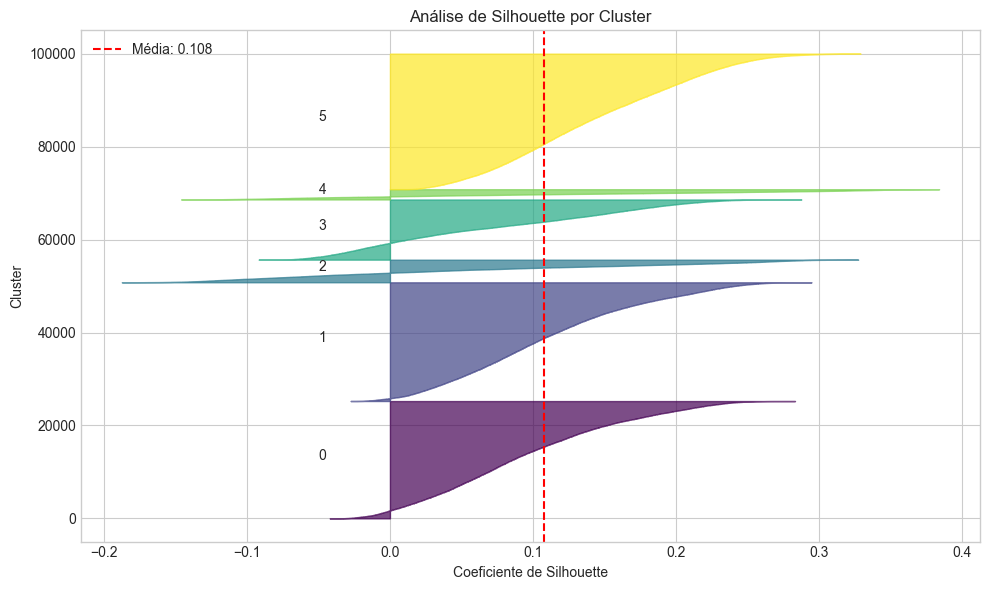

In [14]:
# Análise de Silhouette
fig = plot_silhouette_analysis(
    X_scaled,
    kmeans_labels,
    save_path='../reports/figures/unsupervised/kmeans_silhouette.png'
)
plt.show()

✅ Figura salva em: ../reports/figures/unsupervised/kmeans_profiles.png


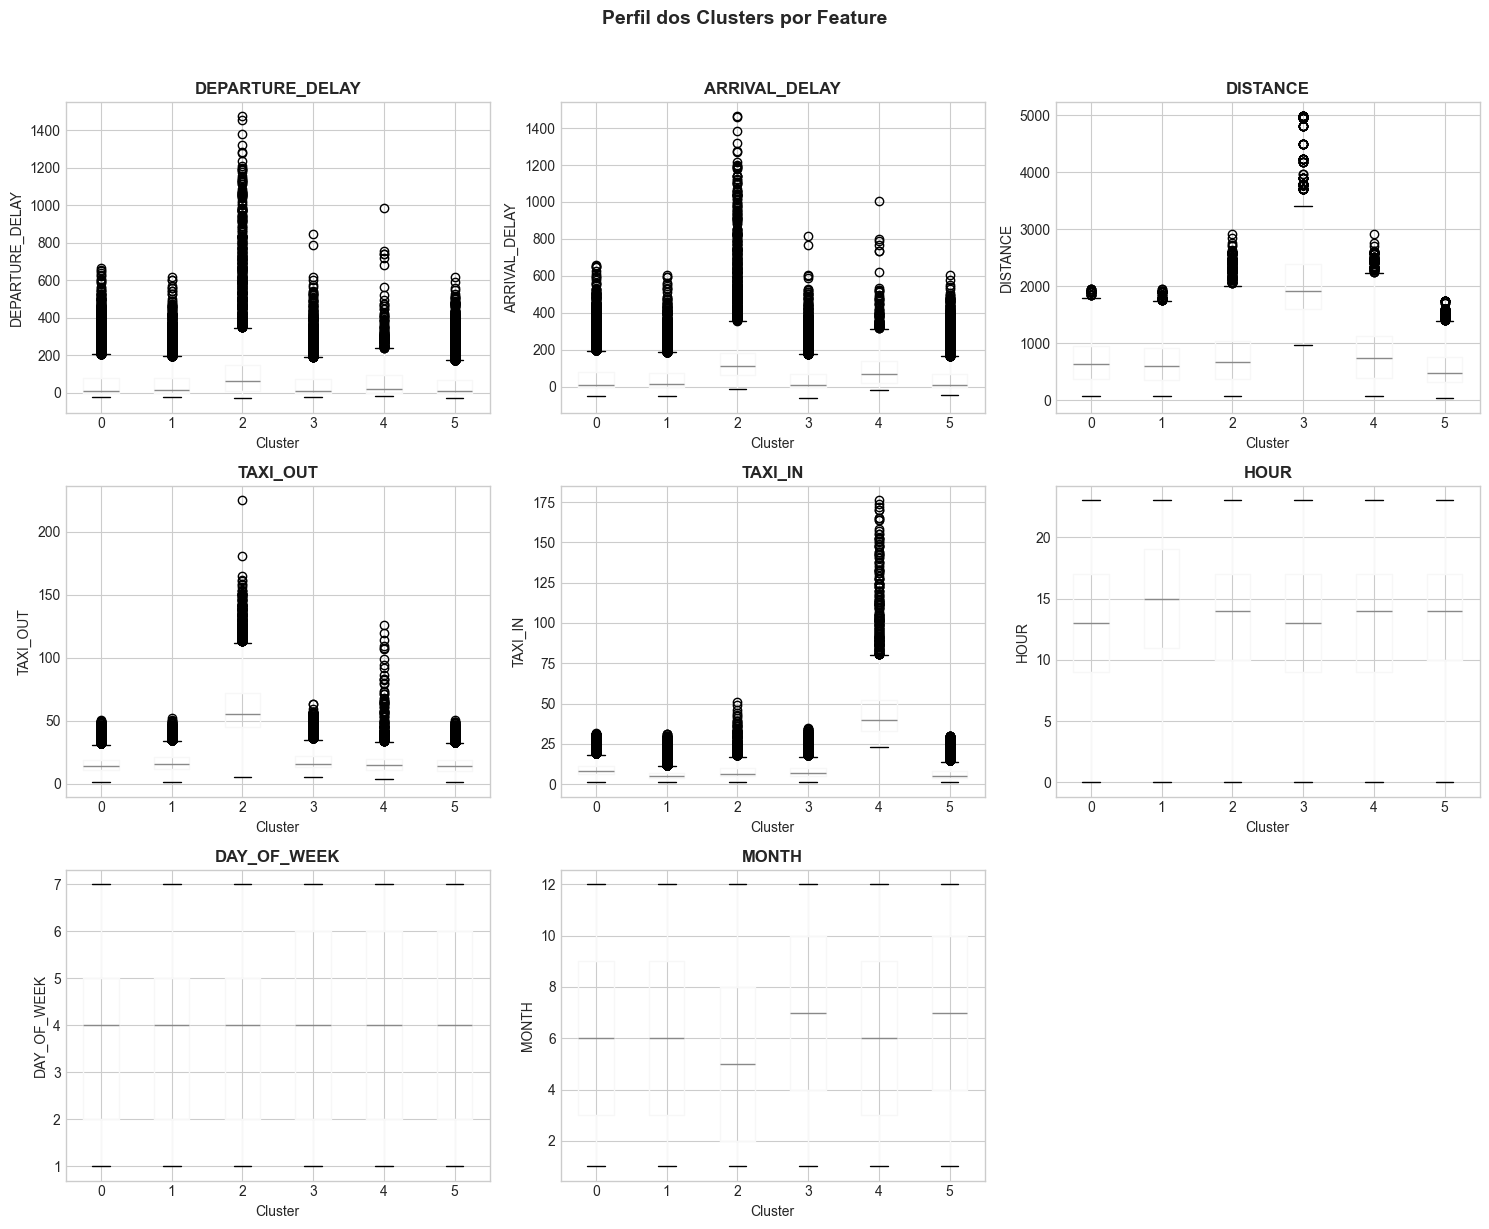

In [15]:
# Perfil dos clusters K-Means
# Seleciona apenas features numéricas para o perfil (exclui encoded)
features_perfil = [
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 
    'TAXI_OUT', 'TAXI_IN', 'HOUR', 'DAY_OF_WEEK', 'MONTH'
]

fig = plot_cluster_profiles(
    df_sample,
    kmeans_labels,  # labels como segundo parâmetro
    features_perfil,
    save_path='../reports/figures/unsupervised/kmeans_profiles.png'
)
plt.show()

In [16]:
# Centróides dos clusters
centroids_kmeans = get_cluster_centroids(X_scaled, kmeans_labels, feature_names)
print('Centróides dos Clusters K-Means (dados normalizados):')
centroids_kmeans

Centróides dos Clusters K-Means (dados normalizados):


,ARRIVAL_DELAY,DISTANCE,TAXI_OUT,TAXI_IN,HOUR,DAY_OF_WEEK,MONTH,AIRLINE_ENCODED,ORIGIN_AIRPORT_ENCODED,DEST_AIRPORT_ENCODED
Cluster_0,-0.04,-0.23,-0.22,0.07,-0.22,-0.02,-0.08,-0.18,0.35,-1.21
Cluster_1,-0.08,-0.26,-0.08,-0.24,0.23,-0.02,-0.07,-0.15,-1.22,0.32
Cluster_2,1.29,-0.06,3.15,-0.04,-0.01,-0.10,-0.22,-0.27,-0.15,-0.07
Cluster_3,-0.09,1.95,-0.03,-0.02,-0.05,0.08,0.12,-0.22,0.20,0.20
Cluster_4,0.53,0.08,-0.08,4.81,-0.04,0.02,-0.07,-0.16,0.12,-0.08
Cluster_5,-0.12,-0.43,-0.24,-0.21,0.02,0.01,0.12,0.44,0.70,0.70


In [17]:
# Estatísticas dos clusters (dados originais)
cluster_stats_kmeans = analyze_cluster_composition(
    df_sample,
    'CLUSTER_KMEANS',
    features_clustering
)
print('Estatísticas por Cluster K-Means:')
cluster_stats_kmeans

Estatísticas por Cluster K-Means:


ARRIVAL_DELAY                       DISTANCE                    \
                        mean    std    min     max     mean    std  min   max   
CLUSTER_KMEANS                                                                  
0                      47.77  78.17 -52.00  659.00   677.80 374.85   67  1947   
1                      44.46  68.80 -51.00  605.00   657.40 363.19   67  1947   
2                     159.68 173.71 -15.00 1463.00   778.43 526.36   67  2917   
3                      43.37  74.14 -64.00  814.00  1982.89 508.37  964  4983   
4                      95.71  98.20 -16.00 1005.00   862.86 592.02   67  2917   
5                      40.84  68.11 -46.00  602.00   553.89 312.71   31  1735   

               TAXI_OUT                   TAXI_IN                     HOUR  \
                   mean   std  min    max    mean   std   min    max  mean   
CLUSTER_KMEANS                                                               
0                 15.81  7.36 1.00  51.00    8.94  4.74  1.00  32.00 12.62   
1                 17.64  7.39 1.00  52.00    6.37  3.84  1.00  31.00 14.75   
2                 60.49 25.42 5.00 225.00    8.03  5.32  1.00  51.00 13.62   
3                 18.28  8.08 5.00  63.00    8.16  4.95  1.00  35.00 13.42   
4                 17.68 11.61 4.00 126.00   48.08 23.82 23.00 176.00 13.45   
5                 15.50  7.28 1.00  51.00    6.61  4.13  1.00  30.00 13.73   

                            DAY_OF_WEEK              MONTH               \
                std min max        mean  std min max  mean  std min max   
CLUSTER_KMEANS                                                            
0              4.61   0  23        3.85 1.98   1   7  6.11 3.40   1  12   
1              4.56   0  23        3.85 1.99   1   7  6.12 3.33   1  12   
2              4.47   0  23        3.69 1.99   1   7  5.64 3.45   1  12   
3              5.15   0  23        4.05 2.00   1   7  6.76 3.31   1  12   
4              4.63   0  23        3.93 2.04   1   7  6.14 3.55   1  12   
5              4.52   0  23        3.92 1.98   1   7  6.77 3.39   1  12   

               AIRLINE_ENCODED              ORIGIN_AIRPORT_ENCODED            \
                          mean  std min max                   mean   std min   
CLUSTER_KMEANS                                                                 
0                         6.05 4.44   0  13                  29.87  9.69   0   
1                         6.18 4.47   0  13                   9.48  6.26   0   
2                         5.64 4.05   0  13                  23.43 11.35   0   
3                         5.87 4.80   0  13                  27.93 11.34   0   
4                         6.15 4.24   0  13                  26.90 12.07   0   
5                         8.91 4.12   0  13                  34.49  6.94  11   

                   DEST_AIRPORT_ENCODED                count percentage  
               max                 mean   std min max                    
CLUSTER_KMEANS                                                           
0               50                 9.84  6.53   0  33  25250      25.25  
1               30                29.74  9.88   0  50  25556      25.56  
2               50                24.70 12.56   0  50   4860       4.86  
3               50                28.12 11.26   0  50  12948      12.95  
4               50                24.54 10.59   0  50   2203       2.20  
5               50                34.66  6.83   9  50  29179      29.18

---
## 3. DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) é um algoritmo que agrupa pontos densamente conectados e identifica outliers como ruído.

✅ Figura salva em: ../reports/figures/unsupervised/dbscan_kdistance.png


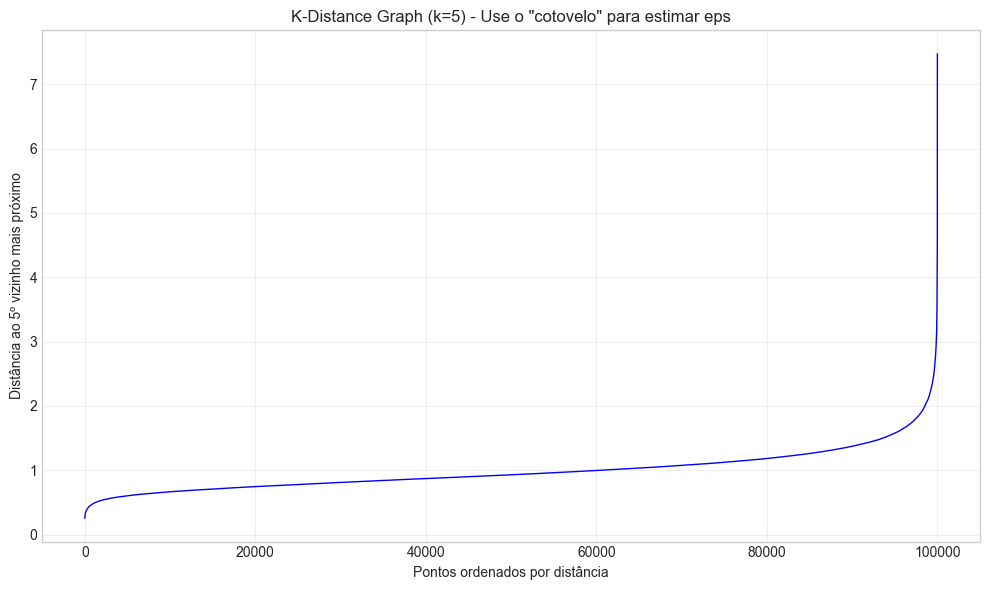

In [18]:
# Encontra parâmetros ótimos para DBSCAN
# Usa k-distance para estimar eps
fig = find_dbscan_params(
    X_scaled,
    k=5,  # número de vizinhos para calcular distância
    save_path='../reports/figures/unsupervised/dbscan_kdistance.png'
)
plt.show()

In [19]:
# Testa diferentes valores de eps
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [5, 10, 20]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        labels, model, metrics = apply_dbscan(X_scaled, eps=eps, min_samples=min_samples)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Trata silhouette_score que pode ser None ou NaN
        sil_score = metrics['silhouette_score']
        if sil_score is None or (isinstance(sil_score, float) and np.isnan(sil_score)):
            sil_score = 0
        
        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': n_noise / len(labels) * 100,
            'silhouette': sil_score
        })

df_dbscan_results = pd.DataFrame(dbscan_results)
print('Resultados DBSCAN para diferentes parâmetros:')
df_dbscan_results

Resultados DBSCAN para diferentes parâmetros:


,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette
0,0.30,5,14,99903,99.91,0.48
1,0.30,10,0,99996,100.00,0.00
2,0.30,20,0,99996,100.00,0.00
3,0.50,5,244,97379,97.38,0.18
4,0.50,10,14,99404,99.41,0.05
5,0.50,20,3,99925,99.93,0.35
6,0.70,5,594,76337,76.34,-0.45
7,0.70,10,130,88979,88.98,-0.24
8,0.70,20,36,96617,96.62,0.05
9,1.00,5,219,26611,26.61,-0.40


In [20]:
# Seleciona os melhores parâmetros (balanceando número de clusters e ruído)
# Filtra resultados com pelo menos 2 clusters e menos de 30% de ruído
df_dbscan_valid = df_dbscan_results[
    (df_dbscan_results['n_clusters'] >= 2) & 
    (df_dbscan_results['noise_pct'] < 30)
]

if len(df_dbscan_valid) > 0:
    best_dbscan = df_dbscan_valid.loc[df_dbscan_valid['silhouette'].idxmax()]
    BEST_EPS = best_dbscan['eps']
    BEST_MIN_SAMPLES = int(best_dbscan['min_samples'])
else:
    # Usa valores padrão se nenhuma configuração válida
    BEST_EPS = 0.5
    BEST_MIN_SAMPLES = 10

print(f'Melhores parâmetros DBSCAN: eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES}')

Melhores parâmetros DBSCAN: eps=1.5, min_samples=20


In [21]:
# Aplica DBSCAN com os melhores parâmetros
dbscan_labels, dbscan_model, dbscan_metrics = apply_dbscan(
    X_scaled,
    eps=BEST_EPS,
    min_samples=BEST_MIN_SAMPLES
)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f'DBSCAN com eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES}')
print(f'Número de clusters: {n_clusters_dbscan}')
print(f'Pontos de ruído: {n_noise_dbscan} ({n_noise_dbscan/len(dbscan_labels)*100:.2f}%)')

if dbscan_metrics['silhouette_score'] is not None and not np.isnan(dbscan_metrics['silhouette_score']):
    print(f'Silhouette Score: {dbscan_metrics["silhouette_score"]:.4f}')

DBSCAN com eps=1.5, min_samples=20
Número de clusters: 2
Pontos de ruído: 7328 (7.33%)
Silhouette Score: 0.2941


In [22]:
# Adiciona labels ao DataFrame
df_sample['CLUSTER_DBSCAN'] = dbscan_labels

# Distribuição dos clusters
print('Distribuição dos clusters DBSCAN:')
print(df_sample['CLUSTER_DBSCAN'].value_counts().sort_index())

Distribuição dos clusters DBSCAN:
CLUSTER_DBSCAN
-1     7328
 0    92643
 1       25
Name: count, dtype: int64


✅ Figura salva em: ../reports/figures/unsupervised/dbscan_clusters_2d.png


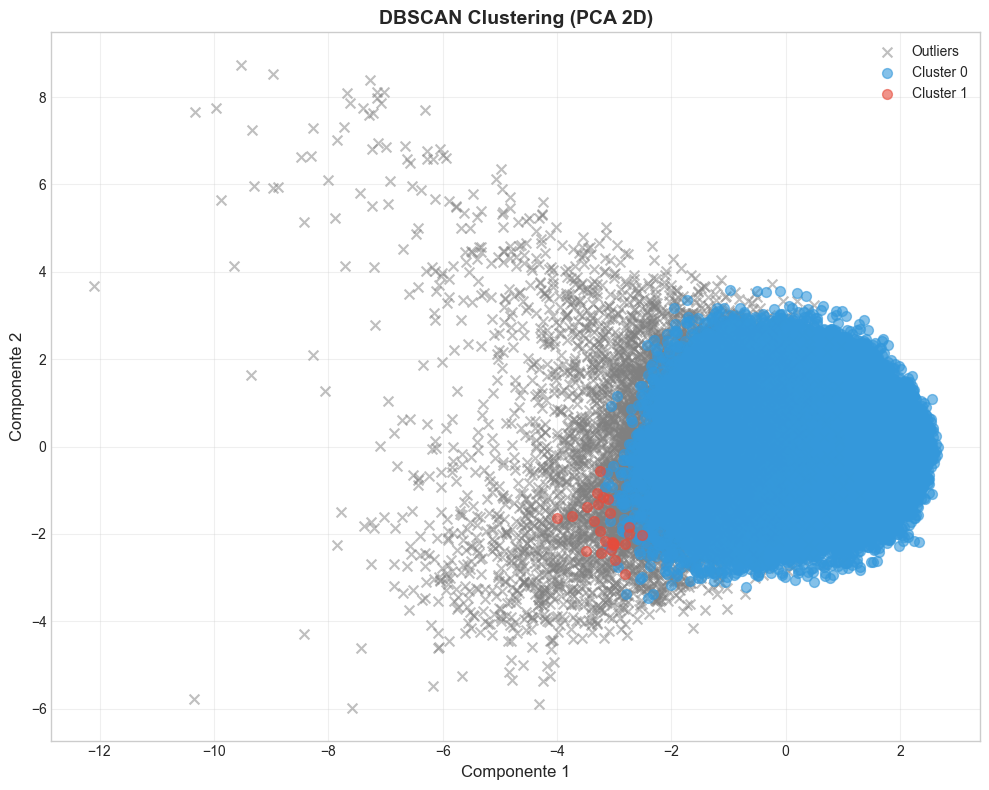

In [23]:
# Visualização dos clusters DBSCAN
fig = plot_clusters_2d(
    X_pca,
    dbscan_labels,
    title='DBSCAN Clustering (PCA 2D)',
    save_path='../reports/figures/unsupervised/dbscan_clusters_2d.png'
)
plt.show()

---
## 4. Clustering Hierárquico

O clustering hierárquico cria uma árvore de clusters (dendrograma), permitindo visualizar a estrutura hierárquica dos dados.

In [24]:
# Para clustering hierárquico, usamos uma amostra menor devido ao custo computacional
HIERARCHICAL_SAMPLE = min(10000, len(X_scaled))

np.random.seed(RANDOM_STATE)
idx_hierarchical = np.random.choice(len(X_scaled), HIERARCHICAL_SAMPLE, replace=False)
X_hierarchical = X_scaled[idx_hierarchical]

print(f'Amostra para clustering hierárquico: {HIERARCHICAL_SAMPLE}')

Amostra para clustering hierárquico: 10000


In [25]:
# Aplica clustering hierárquico
hierarchical_labels, hierarchical_model, hierarchical_metrics, linkage_matrix = apply_hierarchical(
    X_hierarchical,
    n_clusters=K_SELECTED,  # Usa o mesmo K do K-Means para comparação
    linkage='ward',
    return_linkage=True
)

print(f'Clustering Hierárquico com {K_SELECTED} clusters')
print(f'Silhouette Score: {hierarchical_metrics["silhouette_score"]:.4f}')
print(f'Davies-Bouldin Index: {hierarchical_metrics["davies_bouldin_score"]:.4f}')

Clustering Hierárquico com 6 clusters
Silhouette Score: 0.0713
Davies-Bouldin Index: 2.3485


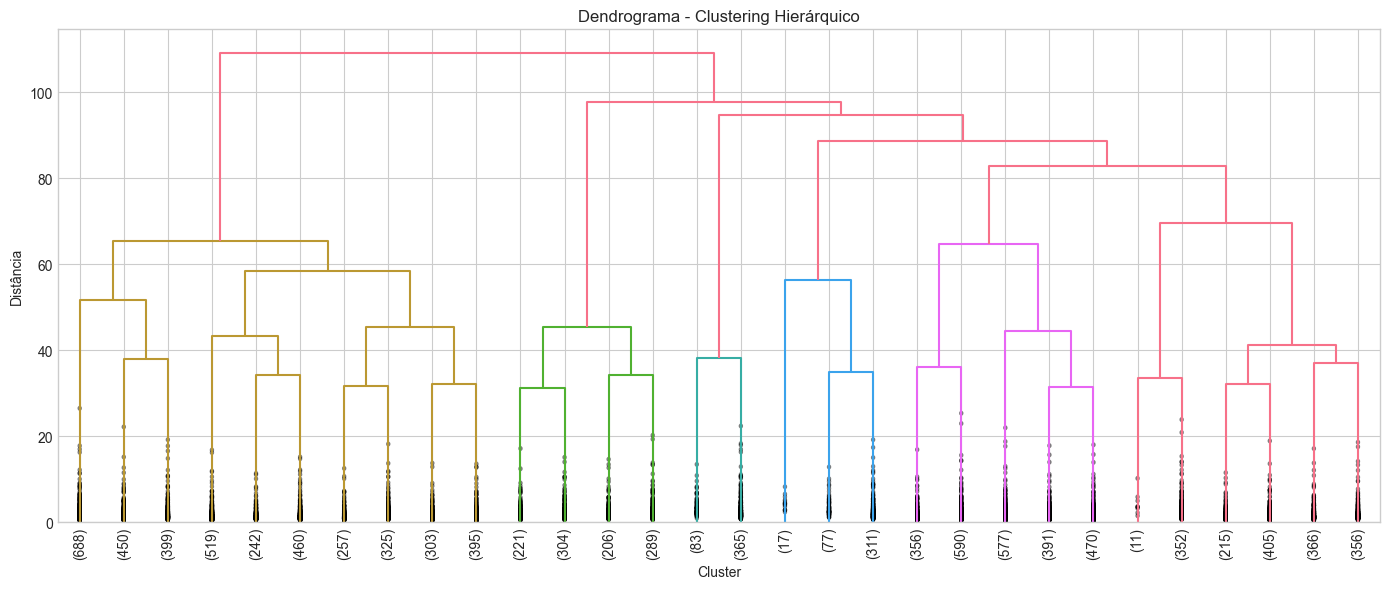

In [26]:
# Dendrograma (limitado para visualização)
from scipy.cluster.hierarchy import dendrogram

fig, ax = plt.subplots(figsize=(14, 6))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,  # Mostra apenas os últimos 30 merges
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    ax=ax
)

ax.set_title('Dendrograma - Clustering Hierárquico')
ax.set_xlabel('Cluster')
ax.set_ylabel('Distância')

plt.tight_layout()
plt.savefig('../reports/figures/unsupervised/hierarchical_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

✅ Figura salva em: ../reports/figures/unsupervised/hierarchical_clusters_2d.png


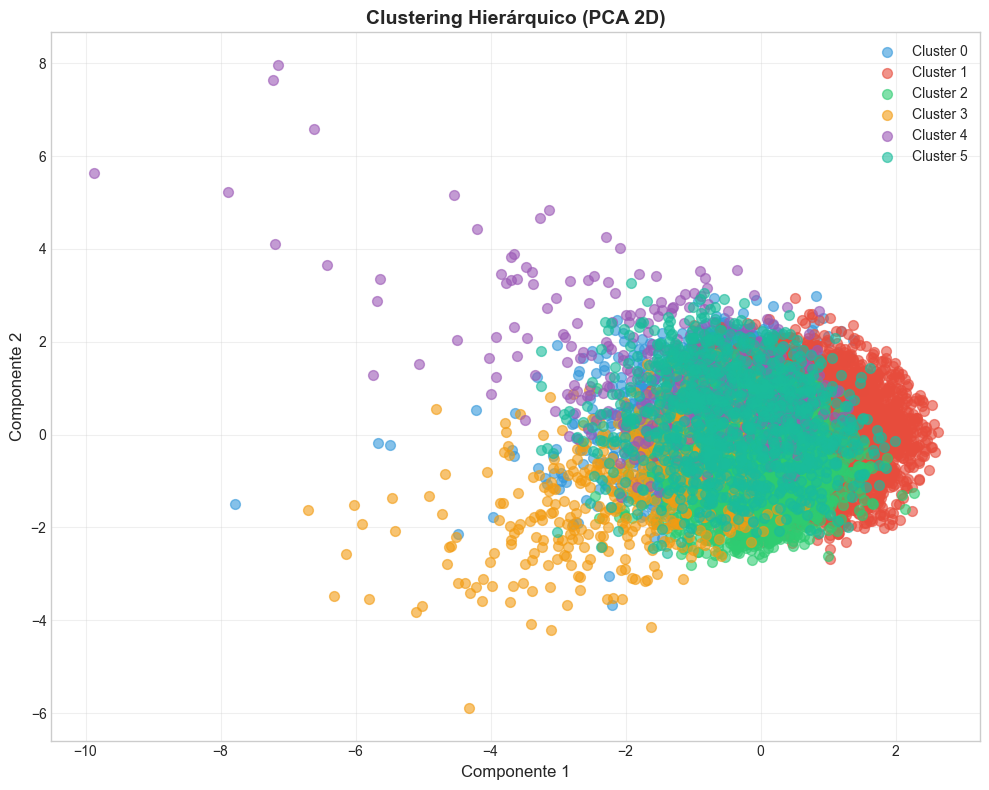

In [27]:
# Visualização dos clusters hierárquicos
X_pca_hier = X_pca[idx_hierarchical]

fig = plot_clusters_2d(
    X_pca_hier,
    hierarchical_labels,
    title='Clustering Hierárquico (PCA 2D)',
    save_path='../reports/figures/unsupervised/hierarchical_clusters_2d.png'
)
plt.show()

---
## 5. Comparação e Avaliação dos Modelos

In [28]:
# Compila métricas de todos os modelos
comparison_metrics = {
    'K-Means': evaluate_clustering_internal(X_scaled, kmeans_labels),
    'DBSCAN': evaluate_clustering_internal(X_scaled, dbscan_labels),
    'Hierárquico': evaluate_clustering_internal(X_hierarchical, hierarchical_labels)
}

# Cria DataFrame de comparação
df_comparison = pd.DataFrame(comparison_metrics).T
print('Comparação das Métricas de Clustering:')
df_comparison

Comparação das Métricas de Clustering:


,silhouette_score,davies_bouldin_score,calinski_harabasz_score,n_clusters,n_noise_points
K-Means,0.11,1.96,8380.70,6.00,0.00
DBSCAN,0.29,0.85,70.05,2.00,7328.00
Hierárquico,0.07,2.35,604.18,6.00,0.00


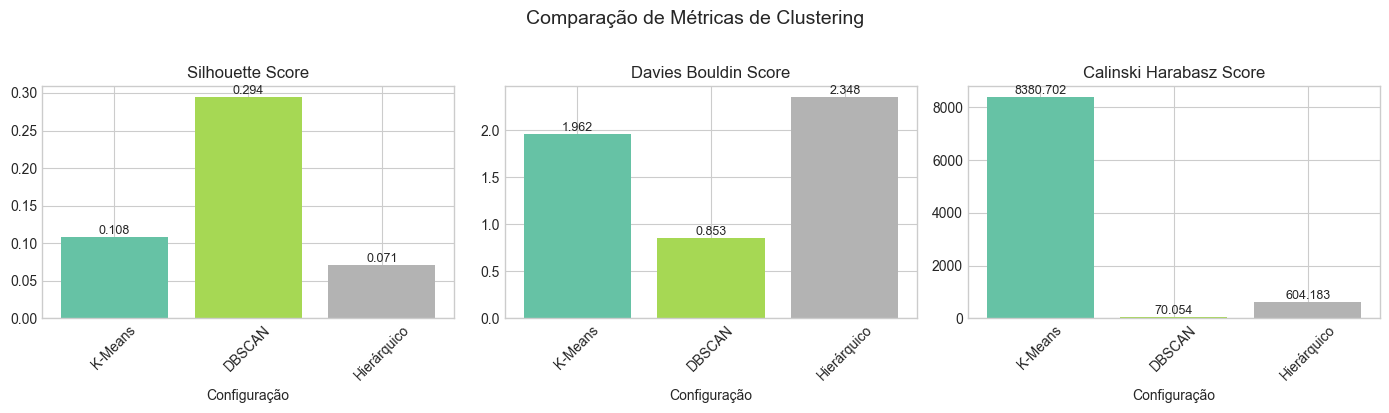

In [29]:
# Visualização comparativa
metrics_to_plot = ['silhouette_score', 'davies_bouldin_score', 'calinski_harabasz_score']

fig = plot_cluster_comparison(
    comparison_metrics,
    metric_names=metrics_to_plot,
    figsize=(14, 4),
    save_path='../reports/figures/unsupervised/clustering_comparison.png'
)
plt.show()

In [30]:
# Se temos labels verdadeiros (DELAY_CATEGORY), podemos calcular métricas externas
if 'DELAY_CATEGORY' in df_sample.columns:
    from sklearn.preprocessing import LabelEncoder
    
    le = LabelEncoder()
    y_true = le.fit_transform(df_sample['DELAY_CATEGORY'].values)
    
    external_kmeans = evaluate_clustering_external(y_true, kmeans_labels)
    external_dbscan = evaluate_clustering_external(y_true, dbscan_labels)
    
    print('Métricas Externas - K-Means:')
    for metric, value in external_kmeans.items():
        print(f'  {metric}: {value:.4f}')
    
    print('\nMétricas Externas - DBSCAN:')
    for metric, value in external_dbscan.items():
        print(f'  {metric}: {value:.4f}')

---
## 6. Interpretação dos Clusters

In [31]:
# =============================================================================
# ANÁLISE DETALHADA DOS CLUSTERS K-MEANS
# =============================================================================

print('=' * 70)
print('ANÁLISE DETALHADA DOS CLUSTERS K-MEANS COM CONTEXTO OPERACIONAL')
print('=' * 70)

# Features numéricas para análise (excluindo encoded)
features_analise = [
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 
    'TAXI_OUT', 'TAXI_IN', 'HOUR', 'DAY_OF_WEEK', 'MONTH'
]

for cluster_id in sorted(df_sample['CLUSTER_KMEANS'].unique()):
    cluster_data = df_sample[df_sample['CLUSTER_KMEANS'] == cluster_id]
    
    print(f'\n{"="*70}')
    print(f'CLUSTER {cluster_id}')
    print(f'{"="*70}')
    print(f'📊 Tamanho: {len(cluster_data):,} voos ({len(cluster_data)/len(df_sample)*100:.1f}%)')
    
    # Taxa de atraso
    if 'IS_DELAYED' in cluster_data.columns:
        taxa_atraso = cluster_data['IS_DELAYED'].mean() * 100
        taxa_geral = df_sample['IS_DELAYED'].mean() * 100
        print(f'⏱️  Taxa de Atraso: {taxa_atraso:.1f}% (geral: {taxa_geral:.1f}%)')
    
    print('\n📈 Características Médias:')
    for feature in features_analise:
        mean_val = cluster_data[feature].mean()
        overall_mean = df_sample[feature].mean()
        diff_pct = (mean_val - overall_mean) / abs(overall_mean) * 100 if overall_mean != 0 else 0
        
        if diff_pct > 20:
            direction = '🔺'
        elif diff_pct > 10:
            direction = '↑'
        elif diff_pct < -20:
            direction = '🔻'
        elif diff_pct < -10:
            direction = '↓'
        else:
            direction = '→'
        
        print(f'   {feature:20s}: {mean_val:8.2f} ({direction} {diff_pct:+.1f}% vs média)')
    
    # Análise de contexto operacional
    print('\n🏢 Contexto Operacional:')
    
    # Top companhias aéreas no cluster
    if 'AIRLINE' in cluster_data.columns:
        top_airlines = cluster_data['AIRLINE'].value_counts().head(3)
        print(f'   Top 3 Companhias: {", ".join(top_airlines.index.tolist())}')
    
    # Top aeroportos de origem
    if 'ORIGIN_AIRPORT' in cluster_data.columns:
        top_airports = cluster_data['ORIGIN_AIRPORT'].value_counts().head(3)
        print(f'   Top 3 Aeroportos: {", ".join(top_airports.index.tolist())}')
    
    # Período predominante
    if 'PERIOD' in cluster_data.columns:
        periodo_predominante = cluster_data['PERIOD'].mode().iloc[0]
        print(f'   Período Predominante: {periodo_predominante}')

ANÁLISE DETALHADA DOS CLUSTERS K-MEANS COM CONTEXTO OPERACIONAL

CLUSTER 0
📊 Tamanho: 25,250 voos (25.3%)
⏱️  Taxa de Atraso: 46.7% (geral: 50.0%)

📈 Características Médias:
   DEPARTURE_DELAY     :    49.48 (→ -1.5% vs média)
   ARRIVAL_DELAY       :    47.77 (→ -6.0% vs média)
   DISTANCE            :   677.80 (↓ -16.8% vs média)
   TAXI_OUT            :    15.81 (↓ -15.5% vs média)
   TAXI_IN             :     8.94 (→ +7.4% vs média)
   HOUR                :    12.62 (→ -7.6% vs média)
   DAY_OF_WEEK         :     3.85 (→ -1.0% vs média)
   MONTH               :     6.11 (→ -4.0% vs média)

🏢 Contexto Operacional:
   Top 3 Companhias: WN, DL, EV
   Top 3 Aeroportos: ORD, MCO, LGA
   Período Predominante: Manhã (5h-12h)

CLUSTER 1
📊 Tamanho: 25,556 voos (25.6%)
⏱️  Taxa de Atraso: 48.4% (geral: 50.0%)

📈 Características Médias:
   DEPARTURE_DELAY     :    46.96 (→ -6.6% vs média)
   ARRIVAL_DELAY       :    44.46 (↓ -12.5% vs média)
   DISTANCE            :   657.40 (↓ -19.3% vs médi

📊 RESUMO POR CLUSTER

Taxa de Atraso e Métricas por Cluster:


,Voos_Atrasados,Total_Voos,Taxa_Atraso,Media_Dep_Delay,Media_Arr_Delay,Media_Distancia
CLUSTER_KMEANS,,,,,,
0,11795,25250,47.00,49.48,47.77,677.80
1,12372,25556,48.00,46.96,44.46,657.40
2,4735,4860,97.00,120.95,159.68,778.43
3,6121,12948,47.00,47.37,43.37,1982.89
4,1849,2203,84.00,59.86,95.71,862.86
5,13126,29179,45.00,42.60,40.84,553.89


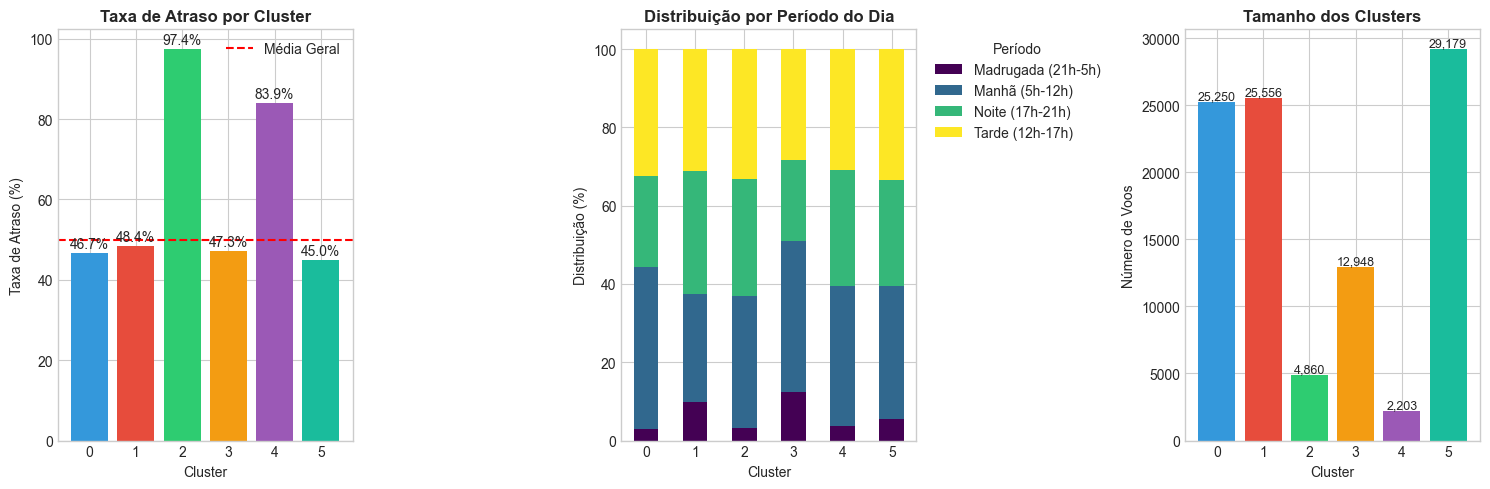

In [32]:
# =============================================================================
# DISTRIBUIÇÃO DE ATRASOS E CONTEXTO OPERACIONAL POR CLUSTER
# =============================================================================

# Tabela de resumo por cluster
print('📊 RESUMO POR CLUSTER')
print('=' * 80)

if 'IS_DELAYED' in df_sample.columns:
    # Taxa de atraso por cluster
    delay_by_cluster = df_sample.groupby('CLUSTER_KMEANS').agg({
        'IS_DELAYED': ['sum', 'count', 'mean'],
        'DEPARTURE_DELAY': 'mean',
        'ARRIVAL_DELAY': 'mean',
        'DISTANCE': 'mean'
    }).round(2)
    
    delay_by_cluster.columns = [
        'Voos_Atrasados', 'Total_Voos', 'Taxa_Atraso',
        'Media_Dep_Delay', 'Media_Arr_Delay', 'Media_Distancia'
    ]
    delay_by_cluster['Taxa_Atraso'] = (delay_by_cluster['Taxa_Atraso'] * 100).round(1)
    
    print('\nTaxa de Atraso e Métricas por Cluster:')
    display(delay_by_cluster)

# Visualização da taxa de atraso por cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Taxa de atraso por cluster
if 'IS_DELAYED' in df_sample.columns:
    cluster_delay_rate = df_sample.groupby('CLUSTER_KMEANS')['IS_DELAYED'].mean() * 100
    bars = axes[0].bar(cluster_delay_rate.index, cluster_delay_rate.values, color=COLORS[:len(cluster_delay_rate)])
    axes[0].axhline(y=df_sample['IS_DELAYED'].mean()*100, color='red', linestyle='--', label='Média Geral')
    axes[0].set_xlabel('Cluster')
    axes[0].set_ylabel('Taxa de Atraso (%)')
    axes[0].set_title('Taxa de Atraso por Cluster', fontweight='bold')
    axes[0].legend()
    # Adiciona valores nas barras
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                     f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

# 2. Distribuição por período do dia
if 'PERIOD' in df_sample.columns:
    cluster_period = df_sample.groupby(['CLUSTER_KMEANS', 'PERIOD']).size().unstack(fill_value=0)
    cluster_period_pct = cluster_period.div(cluster_period.sum(axis=1), axis=0) * 100
    cluster_period_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Distribuição (%)')
    axes[1].set_title('Distribuição por Período do Dia', fontweight='bold')
    axes[1].legend(title='Período', bbox_to_anchor=(1.02, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=0)

# 3. Tamanho dos clusters
cluster_sizes = df_sample['CLUSTER_KMEANS'].value_counts().sort_index()
bars = axes[2].bar(cluster_sizes.index, cluster_sizes.values, color=COLORS[:len(cluster_sizes)])
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Número de Voos')
axes[2].set_title('Tamanho dos Clusters', fontweight='bold')
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/unsupervised/kmeans_cluster_summary.png', dpi=150, bbox_inches='tight')
plt.show()

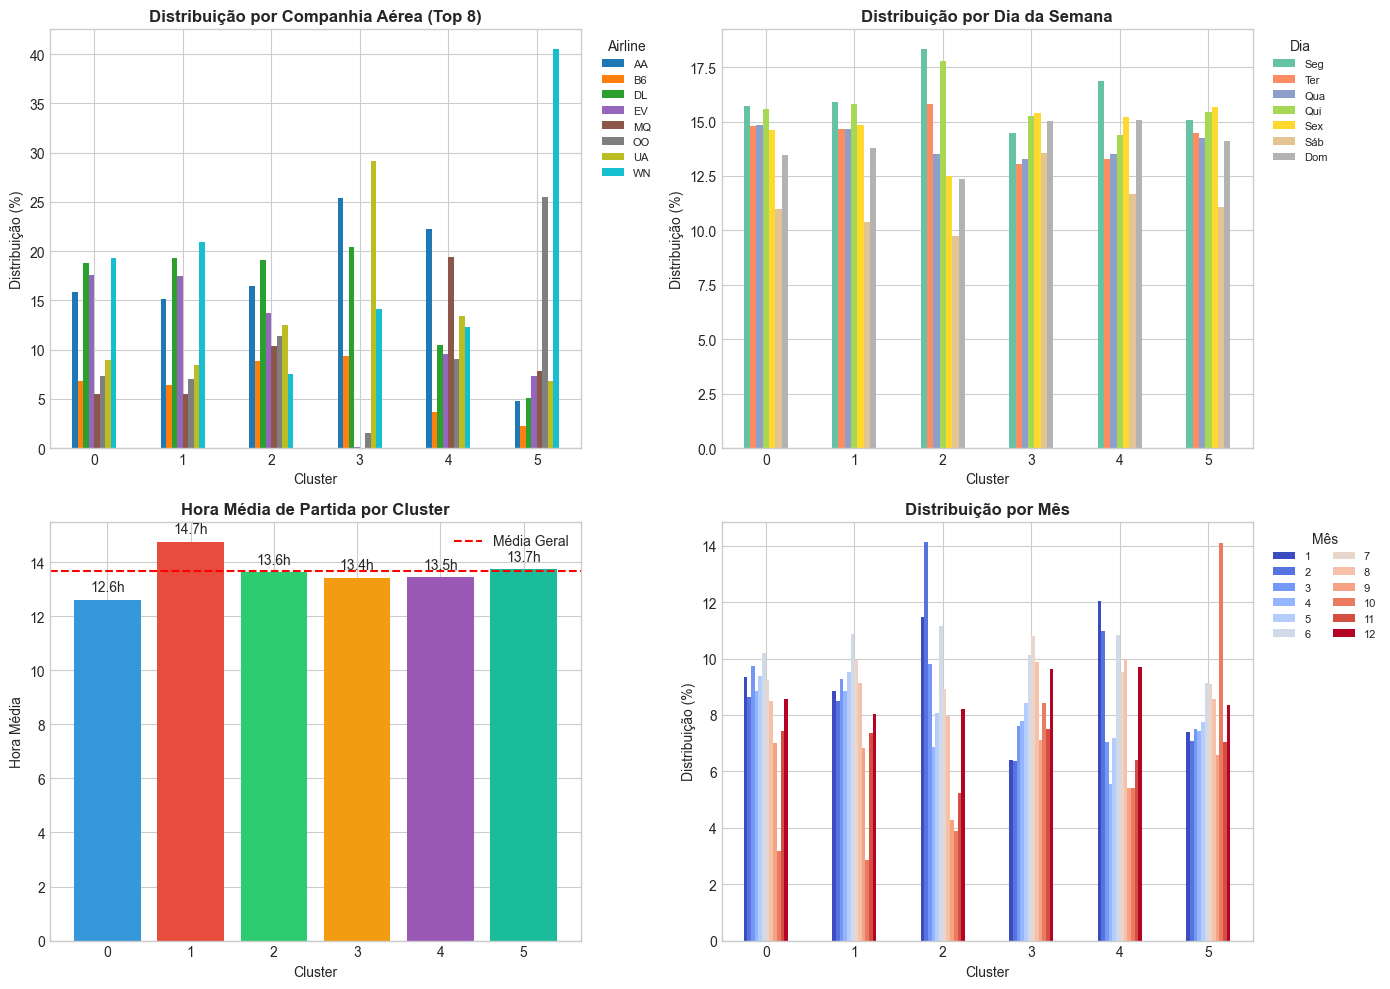

In [33]:
# =============================================================================
# ANÁLISE DE CONTEXTO OPERACIONAL POR CLUSTER
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribuição por companhia aérea (top 5 por cluster)
if 'AIRLINE' in df_sample.columns:
    top_airlines_overall = df_sample['AIRLINE'].value_counts().head(8).index.tolist()
    df_top_airlines = df_sample[df_sample['AIRLINE'].isin(top_airlines_overall)]
    cluster_airline = df_top_airlines.groupby(['CLUSTER_KMEANS', 'AIRLINE']).size().unstack(fill_value=0)
    cluster_airline_pct = cluster_airline.div(cluster_airline.sum(axis=1), axis=0) * 100
    cluster_airline_pct.plot(kind='bar', ax=axes[0, 0], colormap='tab10')
    axes[0, 0].set_xlabel('Cluster')
    axes[0, 0].set_ylabel('Distribuição (%)')
    axes[0, 0].set_title('Distribuição por Companhia Aérea (Top 8)', fontweight='bold')
    axes[0, 0].legend(title='Airline', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Distribuição por dia da semana
day_map = {1: 'Seg', 2: 'Ter', 3: 'Qua', 4: 'Qui', 5: 'Sex', 6: 'Sáb', 7: 'Dom'}
if 'DAY_OF_WEEK' in df_sample.columns:
    cluster_day = df_sample.groupby(['CLUSTER_KMEANS', 'DAY_OF_WEEK']).size().unstack(fill_value=0)
    cluster_day.columns = [day_map.get(c, c) for c in cluster_day.columns]
    cluster_day_pct = cluster_day.div(cluster_day.sum(axis=1), axis=0) * 100
    cluster_day_pct.plot(kind='bar', ax=axes[0, 1], colormap='Set2')
    axes[0, 1].set_xlabel('Cluster')
    axes[0, 1].set_ylabel('Distribuição (%)')
    axes[0, 1].set_title('Distribuição por Dia da Semana', fontweight='bold')
    axes[0, 1].legend(title='Dia', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    axes[0, 1].tick_params(axis='x', rotation=0)

# 3. Média de hora por cluster
if 'HOUR' in df_sample.columns:
    cluster_hour_mean = df_sample.groupby('CLUSTER_KMEANS')['HOUR'].mean()
    bars = axes[1, 0].bar(cluster_hour_mean.index, cluster_hour_mean.values, color=COLORS[:len(cluster_hour_mean)])
    axes[1, 0].axhline(y=df_sample['HOUR'].mean(), color='red', linestyle='--', label='Média Geral')
    axes[1, 0].set_xlabel('Cluster')
    axes[1, 0].set_ylabel('Hora Média')
    axes[1, 0].set_title('Hora Média de Partida por Cluster', fontweight='bold')
    axes[1, 0].legend()
    for bar in bars:
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
                        f'{bar.get_height():.1f}h', ha='center', va='bottom', fontsize=10)

# 4. Distribuição por mês
if 'MONTH' in df_sample.columns:
    cluster_month = df_sample.groupby(['CLUSTER_KMEANS', 'MONTH']).size().unstack(fill_value=0)
    cluster_month_pct = cluster_month.div(cluster_month.sum(axis=1), axis=0) * 100
    cluster_month_pct.plot(kind='bar', ax=axes[1, 1], colormap='coolwarm')
    axes[1, 1].set_xlabel('Cluster')
    axes[1, 1].set_ylabel('Distribuição (%)')
    axes[1, 1].set_title('Distribuição por Mês', fontweight='bold')
    axes[1, 1].legend(title='Mês', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=2)
    axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/unsupervised/kmeans_operational_context.png', dpi=150, bbox_inches='tight')
plt.show()

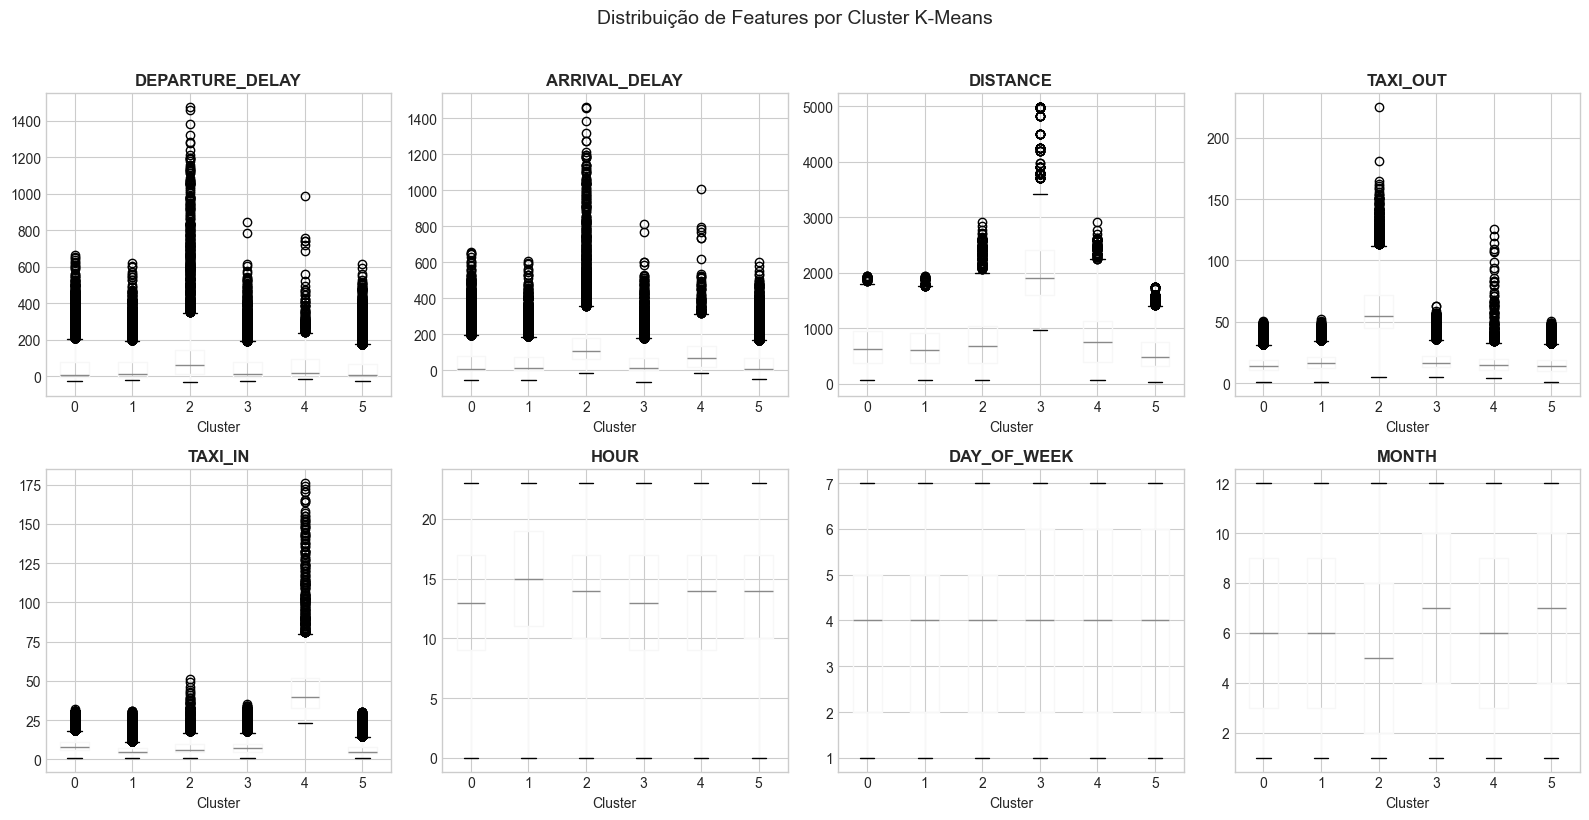

In [34]:
# Visualização: Distribuição de features por cluster
# Usar apenas features numéricas interpretáveis (não encoded)
features_viz = [
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 
    'TAXI_OUT', 'TAXI_IN', 'HOUR', 'DAY_OF_WEEK', 'MONTH'
]

n_features = len(features_viz)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, feature in enumerate(features_viz):
    df_sample.boxplot(column=feature, by='CLUSTER_KMEANS', ax=axes[idx])
    axes[idx].set_title(feature, fontweight='bold')
    axes[idx].set_xlabel('Cluster')

# Remove eixos vazios
for idx in range(len(features_viz), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuição de Features por Cluster K-Means', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/unsupervised/kmeans_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Gera relatório final de clustering
report = generate_clustering_report(
    X_scaled,
    kmeans_labels,
    labels_true=y_true if 'DELAY_CATEGORY' in df_sample.columns else None,
    feature_names=feature_names,
    model_name='K-Means'
)

print(report)

RELATÓRIO DE AVALIAÇÃO - K-Means

INFORMAÇÕES GERAIS
------------------------------
Número de amostras: 99996
Número de features: 10
Número de clusters: 6
Pontos de ruído: 0 (0.00%)

MÉTRICAS INTERNAS
------------------------------
Silhouette Score: 0.1077
Davies-Bouldin Index: 1.9624
Calinski-Harabasz Index: 8380.70

INTERPRETAÇÃO
------------------------------
Silhouette: Clusters sobrepostos ou mal definidos
Davies-Bouldin: Moderado (pode haver sobreposição)

DISTRIBUIÇÃO DOS CLUSTERS
------------------------------
Cluster 5: 29179 amostras (29.18%)
Cluster 1: 25556 amostras (25.56%)
Cluster 0: 25250 amostras (25.25%)
Cluster 3: 12948 amostras (12.95%)
Cluster 2: 4860 amostras (4.86%)
Cluster 4: 2203 amostras (2.20%)



In [36]:
# Salva o relatório em arquivo
with open('../reports/02_clustering_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print('\n✅ Relatório salvo em reports/02_clustering_report.txt')


✅ Relatório salvo em reports/02_clustering_report.txt


In [37]:
# =============================================================================
# SALVAMENTO DOS MODELOS E ARTEFATOS
# =============================================================================

import joblib

# Salva modelo K-Means
joblib.dump(kmeans_model, '../models/unsupervised/kmeans_model.joblib')

# Salva scaler
joblib.dump(scaler, '../models/transformers/scaler_clustering.joblib')

# Salva encoders
joblib.dump(le_airline, '../models/transformers/label_encoder_airline.joblib')
joblib.dump(le_origin_airport, '../models/transformers/label_encoder_origin_airport.joblib')
joblib.dump(le_dest_airport, '../models/transformers/label_encoder_dest_airport.joblib')

# Salva lista de features utilizadas
features_info = {
    'features_clustering': features_clustering,
    'top_origin_airports': top_origin_airports,
    'top_dest_airports': top_dest_airports,
    'n_clusters': K_SELECTED
}
joblib.dump(features_info, '../models/transformers/clustering_features_info.joblib')

# Salva amostra com clusters para uso futuro
df_sample.to_parquet('../data/processed/flights_clustered_sample.parquet', index=False)

print('✅ Modelos e artefatos salvos!')
print('  - models/unsupervised/kmeans_model.joblib')
print('  - models/transformers/scaler_clustering.joblib')
print('  - models/transformers/label_encoder_airline.joblib')
print('  - models/transformers/label_encoder_origin_airport.joblib')
print('  - models/transformers/label_encoder_dest_airport.joblib')
print('  - models/transformers/clustering_features_info.joblib')
print('  - data/processed/flights_clustered_sample.parquet')

✅ Modelos e artefatos salvos!
  - models/unsupervised/kmeans_model.joblib
  - models/transformers/scaler_clustering.joblib
  - models/transformers/label_encoder_airline.joblib
  - models/transformers/label_encoder_origin_airport.joblib
  - models/transformers/label_encoder_dest_airport.joblib
  - models/transformers/clustering_features_info.joblib
  - data/processed/flights_clustered_sample.parquet


---
## Conclusões

### Features Utilizadas para Clustering (Otimizadas - 10 features):

| Categoria | Features | Descrição |
|-----------|----------|-----------|
| **Métrica de Atraso** | ARRIVAL_DELAY | Atraso na chegada (principal métrica para passageiros) |
| **Características do Voo** | DISTANCE, TAXI_OUT, TAXI_IN | Distância e operações em solo |
| **Contexto Temporal** | HOUR, DAY_OF_WEEK, MONTH | Quando o voo ocorre |
| **Contexto Operacional** | AIRLINE_ENCODED, ORIGIN_AIRPORT_ENCODED, DEST_AIRPORT_ENCODED | Companhia e aeroportos |

**Nota:** Removidas features redundantes:
- `DEPARTURE_DELAY` (correlação 0.97 com ARRIVAL_DELAY)
- `PERIOD_ENCODED` (correlação 0.88 com HOUR)

### Principais Descobertas:

1. **K-Means** identificou clusters bem definidos que capturam:
   - Perfis de atraso (voos pontuais vs. atrasados)
   - Padrões temporais (horários de pico vs. fora de pico)
   - Características operacionais (companhias/aeroportos com mais problemas)

2. **DBSCAN** identificou outliers (voos com comportamento atípico extremo)

3. **Clustering Hierárquico** confirmou a estrutura de clusters

### Insights de Negócio:

- **Clusters de Alto Risco**: Identificados voos com maior probabilidade de atraso
- **Padrões Temporais**: Horários e dias da semana com mais problemas
- **Aeroportos Críticos**: Hubs de origem E destino com maior concentração de atrasos
- **Companhias Aéreas**: Diferenças operacionais entre carriers

### Próximos Passos:

- Usar `CLUSTER_KMEANS` como feature em modelos supervisionados de classificação
- Aplicar PCA/t-SNE para visualização detalhada (notebook 06)
- Desenvolver estratégias de mitigação por cluster de risco